In [22]:
import pandas as pd
import numpy as np
import math

# Charger les données
# Lecture du fichier CSV contenant les données publicitaires
# Le dataset contient les dépenses (TV, Radio, Newspaper)
# et les ventes (Sales)
df = pd.read_csv("Advertising.csv")


# Séparer X et y
# X : variables explicatives (features)
# -> dépenses publicitaires
X = df[['TV', 'Radio', 'Newspaper']].values

# y : variable cible (target)
# -> ventes à prédire
y = df['Sales'].values


In [23]:
# Normalisation 
# KNN utilise la distance, donc les variables doivent être
# sur la même échelle (sinon une variable domine les autres)

def normalize(X):
    # formule Min-Max :
    # (x - min) / (max - min)
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# Application de la normalisation
X = normalize(X)

# Train / Test split (80% / 20%)
# On mélange les indices pour éviter un biais
indices = np.arange(len(X))
np.random.shuffle(indices)

# 80% pour l'entraînement, 20% pour le test
split = int(0.8 * len(X))

# Création des indices train/test
train_idx = indices[:split]
test_idx = indices[split:]

# Données d'entraînement (utilisées pour apprendre)
X_train = X[train_idx]
y_train = y[train_idx]

# Données de test (utilisées pour évaluer)
X_test = X[test_idx]
y_test = y[test_idx]


In [24]:
# KNN Regressor from scratch
# Principe :
# 1. Calculer la distance entre le point test et tous les points train
# 2. Trier les distances
# 3. Prendre les k plus proches voisins
# 4. Faire la moyenne de leurs valeurs (régression)

def knn_predict(X_train, y_train, x_test, k=5):
    distances = []

    # Calcul de la distance entre x_test et chaque point du train
    for i in range(len(X_train)):
        d = distance(X_train[i], x_test)
        distances.append((d, y_train[i]))

    # Trier les distances (du plus proche au plus loin)
    distances.sort(key=lambda x: x[0])

    # Sélectionner les k plus proches voisins
    neighbors = distances[:k]

    # Moyenne des valeurs des voisins (régression)
    return sum(val for _, val in neighbors) / k

In [25]:
# Distance euclidienne
# Cette fonction calcule la distance entre deux points
# Formule :
# √( (x1 - y1)^2 + (x2 - y2)^2 + ... )

def distance(a, b):
    return math.sqrt(sum((a[i] - b[i])**2 for i in range(len(a))))


In [26]:
#Prédictions sur les données de TEST
# On applique le modèle sur des données jamais vues

predictions = []

for x in X_test:
    pred = knn_predict(X_train, y_train, x, k=5)
    predictions.append(pred)


# Évaluation du modèle
# MAE : erreur moyenne absolue
# -> facile à interpréter (écart moyen)

def mae(y_true, y_pred):
    return sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_true))) / len(y_true)

# RMSE : racine de l'erreur quadratique moyenne
# -> pénalise plus les grandes erreurs

def rmse(y_true, y_pred):
    return math.sqrt(sum((y_true[i] - y_pred[i])**2 for i in range(len(y_true))) / len(y_true))

# Affichage des résultats
print("\nRésultats sur le TEST :")
print("MAE  =", round(mae(y_test, predictions), 4))
print("RMSE =", round(rmse(y_test, predictions), 4))


#Afficher quelques résultats
# Comparaison entre valeurs réelles et prédites

print("\nExemples de prédictions :")
for i in range(5):
    print(f"Réel: {y_test[i]:.2f} | Prédit: {predictions[i]:.2f}")


Résultats sur le TEST :
MAE  = 0.9905
RMSE = 1.2979

Exemples de prédictions :
Réel: 10.40 | Prédit: 11.48
Réel: 11.50 | Prédit: 12.48
Réel: 26.20 | Prédit: 24.34
Réel: 10.90 | Prédit: 10.90
Réel: 15.00 | Prédit: 14.66


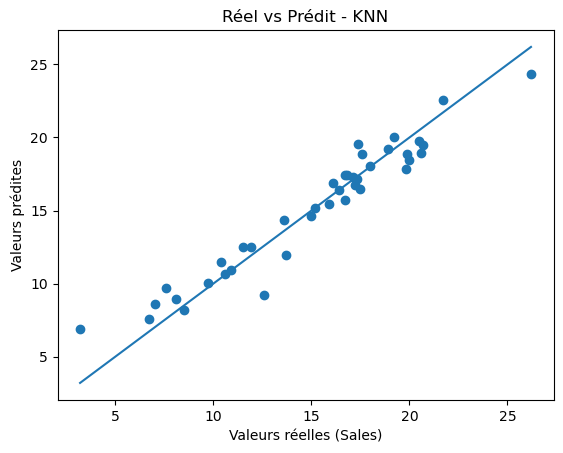

In [27]:
import matplotlib.pyplot as plt

# Graphique scatter : réel vs prédit
plt.figure()
plt.scatter(y_test, predictions)

# Ligne idéale (y = x)
min_val = min(min(y_test), min(predictions))
max_val = max(max(y_test), max(predictions))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Valeurs réelles (Sales)")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit - KNN")

plt.show()